In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

pd.set_option('display.max_columns', None)

### Load Data

In [2]:
sys.path.append(os.path.abspath(".."))

from src.db_connection import get_engine

engine = get_engine()

df = pd.read_sql("""SELECT * FROM vw_games_full_metadata""", engine)
print(df.shape)
df.head()

(239660, 21)


,appid,game_name,type,is_free,required_age,release_date,metacritic_score,recommendations_total,mat_initial_price,mat_final_price,mat_discount_percent,mat_currency,mat_achievement_count,mat_supports_windows,mat_supports_mac,mat_supports_linux,short_description,supported_languages,genres,developers,publishers
0,10,Counter-Strike,game,0,0,2000-11-01,88.0,161854.0,999.0,999.0,0.0,USD,NaN,1,1,1,Play the world's number 1 online action game. ...,"English<strong>*</strong>, French<strong>*</st...",Action,Valve,Valve
1,20,Team Fortress Classic,game,0,0,1999-04-01,NaN,6633.0,499.0,499.0,0.0,USD,NaN,1,1,1,One of the most popular online action games of...,"English, French, German, Italian, Spanish - Sp...",Action,Valve,Valve
2,30,Day of Defeat,game,0,0,2003-05-01,79.0,4308.0,499.0,499.0,0.0,USD,NaN,1,1,1,Enlist in an intense brand of Axis vs. Allied ...,"English, French, German, Italian, Spanish - Spain",Action,Valve,Valve
3,40,Deathmatch Classic,game,0,0,2001-06-01,NaN,2338.0,499.0,499.0,0.0,USD,NaN,1,1,1,Enjoy fast-paced multiplayer gaming with Death...,"English, French, German, Italian, Spanish - Sp...",Action,Valve,Valve
4,50,Half-Life: Opposing Force,game,0,0,1999-11-01,NaN,22793.0,499.0,499.0,0.0,USD,NaN,1,1,1,Return to the Black Mesa Research Facility as ...,"English, French, German, Korean",Action,Gearbox Software,Valve


In [3]:
df[[
    "game_name",
    "genres",
    "developers",
    "publishers"
]].head()

,game_name,genres,developers,publishers
0,Counter-Strike,Action,Valve,Valve
1,Team Fortress Classic,Action,Valve,Valve
2,Day of Defeat,Action,Valve,Valve
3,Deathmatch Classic,Action,Valve,Valve
4,Half-Life: Opposing Force,Action,Gearbox Software,Valve


#### thông tin tổng quan

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 239660 entries, 0 to 239659
Data columns (total 21 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   appid                  239660 non-null  int64  
 1   game_name              239660 non-null  str    
 2   type                   236993 non-null  str    
 3   is_free                239660 non-null  int64  
 4   required_age           239660 non-null  str    
 5   release_date           202809 non-null  str    
 6   metacritic_score       5299 non-null    float64
 7   recommendations_total  22560 non-null   float64
 8   mat_initial_price      144923 non-null  float64
 9   mat_final_price        144923 non-null  float64
 10  mat_discount_percent   144923 non-null  float64
 11  mat_currency           144923 non-null  str    
 12  mat_achievement_count  61401 non-null   float64
 13  mat_supports_windows   239660 non-null  int64  
 14  mat_supports_mac       239660 non-null  int64  

#### thống kê mô tả

In [5]:
df.describe(include='all')

,appid,game_name,type,is_free,required_age,release_date,metacritic_score,recommendations_total,mat_initial_price,mat_final_price,mat_discount_percent,mat_currency,mat_achievement_count,mat_supports_windows,mat_supports_mac,mat_supports_linux,short_description,supported_languages,genres,developers,publishers
count,2.396600e+05,239660,236993,239660.000000,239660,202809,5299.000000,2.256000e+04,1.449230e+05,1.449230e+05,144923.000000,144923,61401.000000,239660.000000,239660.000000,239660.000000,224170,222004,207939,228967,214220
unique,NaN,237760,5,NaN,21,5496,NaN,NaN,NaN,NaN,NaN,33,NaN,NaN,NaN,NaN,206929,30503,3163,96151,86108
top,NaN,Prism,game,NaN,0,2022-05-30,NaN,NaN,NaN,NaN,NaN,USD,NaN,NaN,NaN,NaN,Embark on your adventure with player from all ...,English,"Action, Indie","SmiteWorks USA, LLC",KOMODO
freq,NaN,6,150275,NaN,235668,353,NaN,NaN,NaN,NaN,NaN,142570,NaN,NaN,NaN,NaN,284,54663,9079,3591,2339
mean,2.032250e+06,NaN,NaN,0.201427,NaN,NaN,74.052651,4.648429e+03,2.265139e+04,2.064869e+04,5.361916,NaN,34.411215,0.999975,0.998865,0.998748,NaN,NaN,NaN,NaN,NaN
std,1.068247e+06,NaN,NaN,0.401067,NaN,NaN,10.299116,4.642273e+04,8.571831e+05,7.796022e+05,17.769805,NaN,197.958850,0.005003,0.033670,0.035358,NaN,NaN,NaN,NaN,NaN
min,1.000000e+01,NaN,NaN,0.000000,NaN,NaN,6.000000,1.010000e+02,5.000000e+01,4.400000e+01,0.000000,NaN,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN
25%,1.122595e+06,NaN,NaN,0.000000,NaN,NaN,69.000000,1.740000e+02,2.990000e+02,2.990000e+02,0.000000,NaN,9.000000,1.000000,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN
50%,1.993825e+06,NaN,NaN,0.000000,NaN,NaN,76.000000,3.690000e+02,4.990000e+02,4.990000e+02,0.000000,NaN,17.000000,1.000000,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN
75%,2.946398e+06,NaN,NaN,0.000000,NaN,NaN,81.000000,1.205250e+03,9.990000e+02,9.990000e+02,0.000000,NaN,31.000000,1.000000,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN


#### kiểm tra missing value

In [6]:
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_percent
}).sort_values(by='Missing %', ascending=False)

missing_df

,Missing Count,Missing %
metacritic_score,234361,97.788951
recommendations_total,217100,90.586664
mat_achievement_count,178259,74.379955
mat_initial_price,94737,39.529750
mat_discount_percent,94737,39.529750
mat_currency,94737,39.529750
mat_final_price,94737,39.529750
release_date,36851,15.376367
genres,31721,13.235834
publishers,25440,10.615038


#### visualize missing

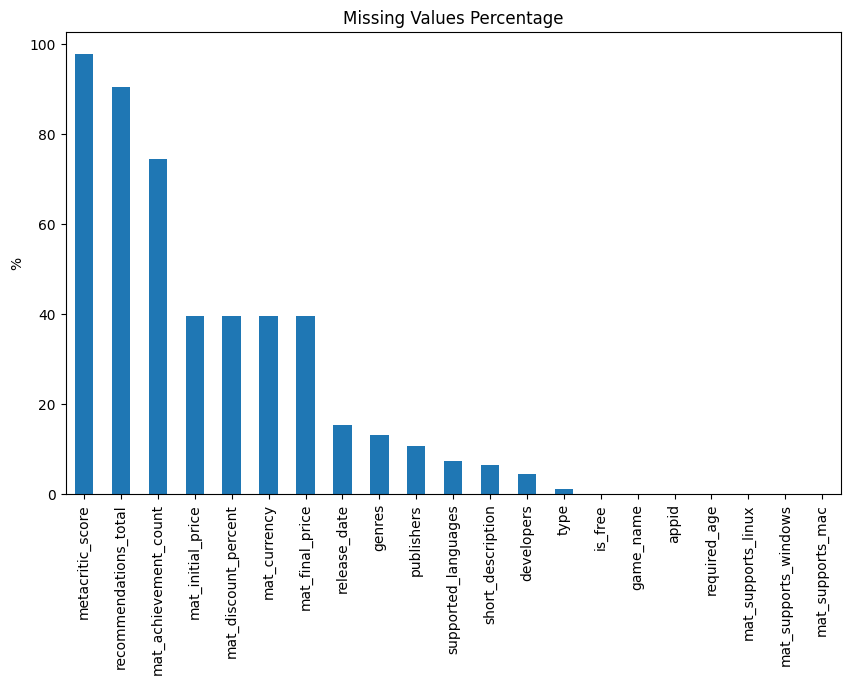

In [7]:
plt.figure(figsize=(10,6))
missing_df['Missing %'].plot(kind='bar')
plt.title("Missing Values Percentage")
plt.ylabel("%")
plt.show()

#### Phân tích genres

In [8]:
df["genres"].value_counts().head(10)

genres
Action, Indie               9079
Action, Adventure, Indie    8894
Casual, Indie               8885
Action                      8401
Adventure, Indie            7073
Action, Casual, Indie       6465
Simulation                  5638
Adventure, Casual, Indie    5326
Indie                       4827
Indie, RPG, Strategy        4658
Name: count, dtype: int64

#### phân tích biến categorical

In [9]:
print("Type distribution:")
print(df['type'].value_counts())

print("\nFree vs Paid:")
print(df['is_free'].value_counts())

Type distribution:
type
game     150275
dlc       53792
demo      23521
music      8713
video       692
Name: count, dtype: int64

Free vs Paid:
is_free
0    191386
1     48274
Name: count, dtype: int64


#### phân tích giá

In [ ]:
df['mat_final_price'].describe()

count    1.449230e+05
mean     2.064869e+04
std      7.796022e+05
min      4.400000e+01
25%      2.990000e+02
50%      4.990000e+02
75%      9.990000e+02
max      8.910000e+07
Name: mat_final_price, dtype: float64

#### histogram giá

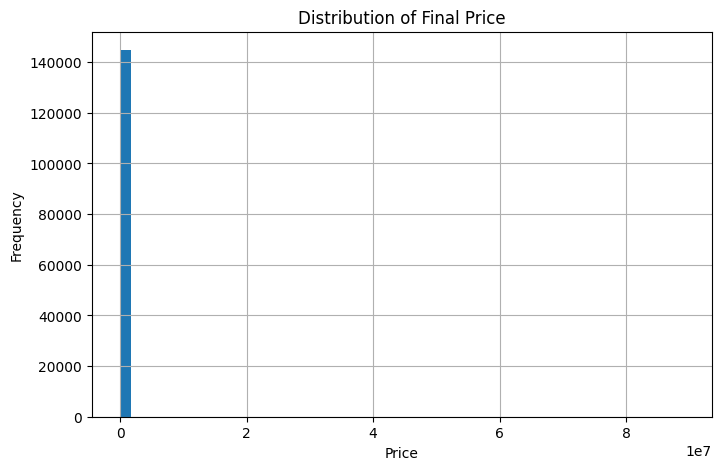

In [11]:
plt.figure(figsize=(8,5))
df['mat_final_price'].hist(bins=50)
plt.title("Distribution of Final Price")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

#### Discount analysis

In [12]:
df['mat_discount_percent'].describe()

count    144923.000000
mean          5.361916
std          17.769805
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          95.000000
Name: mat_discount_percent, dtype: float64

#### check dữ liệu bất thường

In [13]:
print("Negative price:", (df['mat_final_price'] < 0).sum())
print("Discount > 100%:", (df['mat_discount_percent'] > 100).sum())

Negative price: 0
Discount > 100%: 0


#### check trùng lặp

In [14]:
df.duplicated().sum()

np.int64(0)

#### Correlation (numeric)

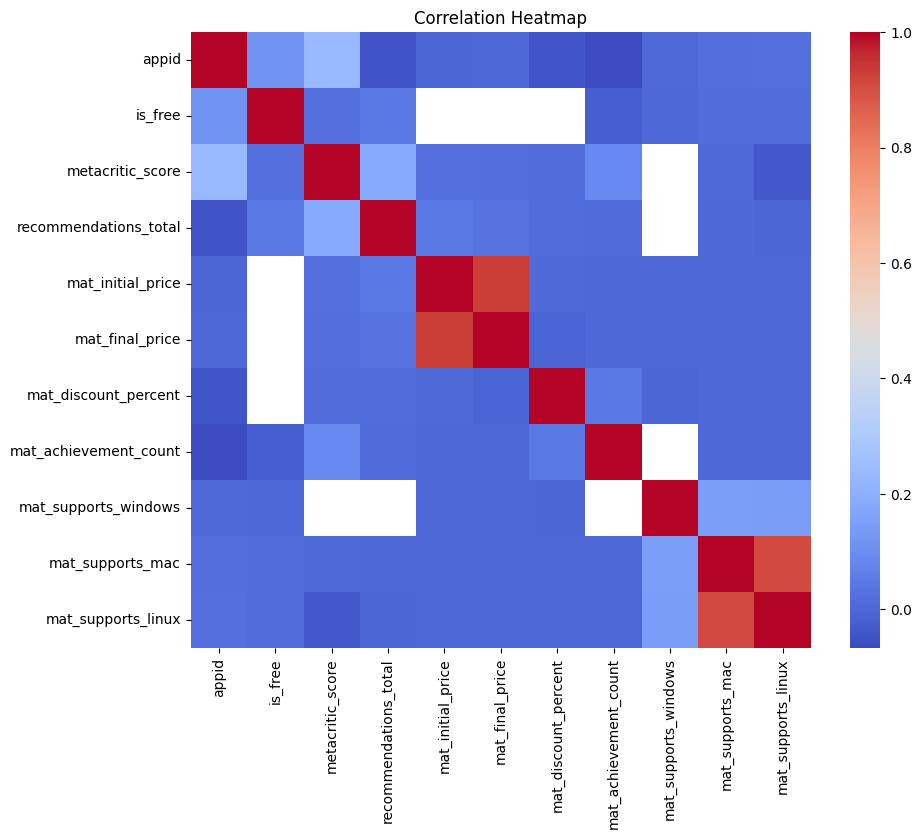

In [15]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(10,8))
sns.heatmap(df[numeric_cols].corr(), annot=False, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

#### một số insight test nhanh

In [16]:
# game free có giá không?
df[df['is_free'] == True]['mat_final_price'].describe()

count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: mat_final_price, dtype: float64

In [17]:
# game có review nhiều
df[['recommendations_total']].describe()

,recommendations_total
count,2.256000e+04
mean,4.648429e+03
std,4.642273e+04
min,1.010000e+02
25%,1.740000e+02
50%,3.690000e+02
75%,1.205250e+03
max,4.661011e+06


In [18]:
# game có điểm metacritic
df[['metacritic_score']].describe()

,metacritic_score
count,5299.000000
mean,74.052651
std,10.299116
min,6.000000
25%,69.000000
50%,76.000000
75%,81.000000
max,97.000000


# Kết luận tổng thể

## 1. Tổng quan dữ liệu

Dữ liệu được lấy từ MySQL thông qua view `vw_games_full_metadata`. View này được tạo bằng cách kết hợp bảng chính `applications` với các bảng metadata như `genres`, `developers` và `publishers`.

Dataset sau khi lấy từ SQL gồm khoảng hơn 239,000 game với nhiều nhóm thông tin quan trọng như:

- Thông tin cơ bản của game: `appid`, `game_name`, `type`, `release_date`
- Thông tin giá: `mat_initial_price`, `mat_final_price`, `mat_discount_percent`
- Thông tin đánh giá: `metacritic_score`, `recommendations_total`
- Thông tin nền tảng hỗ trợ: `mat_supports_windows`, `mat_supports_mac`, `mat_supports_linux`
- Thông tin metadata mở rộng: `genres`, `developers`, `publishers`
- Thông tin mô tả và ngôn ngữ: `short_description`, `supported_languages`

Việc sử dụng dữ liệu từ SQL giúp project mô phỏng quy trình Data Science thực tế hơn, trong đó dữ liệu được lưu trữ và truy vấn từ cơ sở dữ liệu thay vì chỉ đọc trực tiếp từ file CSV.



## 2. Vấn đề missing values

Qua quá trình kiểm tra missing values, dataset tồn tại nhiều cột có tỷ lệ thiếu dữ liệu cao, đặc biệt là:

- `metacritic_score` thiếu rất nhiều dữ liệu
- `recommendations_total` thiếu nhiều dữ liệu
- `mat_achievement_count` thiếu dữ liệu ở mức cao
- Một số cột liên quan đến giá và cấu hình máy cũng có missing values

Điều này cho thấy không phải tất cả game trên Steam đều có đầy đủ thông tin đánh giá, recommendation hoặc metadata chi tiết.

### Nhận định

- Một số feature không thể sử dụng trực tiếp cho mô hình.
- Cần có chiến lược xử lý missing values phù hợp.
- Các cột thiếu quá nhiều có thể cần loại bỏ hoặc chỉ dùng trong phân tích riêng.
- Các cột quan trọng như giá, nền tảng hỗ trợ và ngày phát hành cần được xử lý cẩn thận trong bước preprocessing.



## 3. Dữ liệu giá

Các cột giá như `mat_initial_price`, `mat_final_price` và `mat_discount_percent` là những feature quan trọng trong dataset.

Qua EDA có thể nhận thấy:

- Nhiều game có giá bằng 0, tương ứng với nhóm game miễn phí.
- Dữ liệu giá có xu hướng lệch, do phần lớn game có giá thấp hoặc miễn phí, trong khi một số ít game có giá cao.
- Cần xử lý các giá trị thiếu và các giá trị bất thường trước khi đưa vào mô hình.



## 4. Dữ liệu categorical và metadata

Các cột categorical như `type`, `genres`, `developers`, `publishers` cung cấp nhiều thông tin ngữ cảnh quan trọng.

Đặc biệt, sau khi sử dụng SQL JOIN để tạo view `vw_games_full_metadata`, dataset không chỉ có thông tin từ bảng `applications`, mà còn được bổ sung thêm:

- Thể loại game (`genres`)
- Nhà phát triển (`developers`)
- Nhà phát hành (`publishers`)

Các thông tin này có thể hỗ trợ tốt cho các bước phân tích nâng cao, đặc biệt là hệ khuyến nghị game.



## 5. Dữ liệu bất thường

Một số vấn đề cần kiểm tra kỹ hơn trong các bước sau:

- Game có giá bằng 0 nhưng không được đánh dấu là miễn phí
- Discount percent có thể có giá trị bất thường
- Một số game thiếu thông tin ngày phát hành
- Một số metadata như genre, developer hoặc publisher có thể bị thiếu

Các vấn đề này cần được xử lý trong bước Data Preprocessing để đảm bảo dữ liệu phù hợp cho Machine Learning.



## 6. Feature tiềm năng

Một số feature có tiềm năng sử dụng trong các bước tiếp theo gồm:

- `is_free`
- `required_age`
- `mat_final_price`
- `mat_initial_price`
- `mat_discount_percent`
- `mat_supports_windows`
- `mat_supports_mac`
- `mat_supports_linux`
- `release_date`
- `recommendations_total`
- `genres`
- `developers`
- `publishers`

Trong đó, các feature dạng text hoặc metadata như `genres`, `developers`, `publishers`, `short_description` có thể được sử dụng cho hệ khuyến nghị hoặc các phân tích mở rộng.



## 7. Hướng xử lý tiếp theo

Sau bước EDA, dữ liệu cần được đưa sang bước Preprocessing với các công việc chính:

- Xử lý missing values
- Chuyển đổi kiểu dữ liệu:
  - `required_age` sang numeric
  - `release_date` sang datetime
- Loại bỏ hoặc xử lý các cột thiếu quá nhiều
- Xử lý dữ liệu categorical bằng encoding
- Tạo thêm feature mới nếu cần
- Chuẩn hóa dữ liệu trước khi áp dụng PCA và các mô hình Machine Learning



## 8. Kết luận chung

EDA cho thấy dataset Steam Games có quy mô lớn, nhiều thuộc tính hữu ích và phù hợp để thực hiện các bài toán Data Science như regression, classification, clustering và recommendation system.

Tuy nhiên, dữ liệu cũng tồn tại nhiều vấn đề như missing values, dữ liệu lệch, cột text phức tạp và metadata không đồng đều. Vì vậy, bước preprocessing là bắt buộc để chuẩn bị dữ liệu sạch, nhất quán và phù hợp cho các mô hình Machine Learning ở các phần tiếp theo.